# MNIST Dataset : Digit Recognition Process

In [1]:
import tensorflow as tf

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [3]:
# Load the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
 
# Normalize the input data
x_train = x_train / 255.0
x_test = x_test / 255.0
 
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [4]:
model = Sequential([
    Flatten(input_shape=(28, 28)),     # 28x28 images to 784 input features
    Dense(128, activation='relu'),     # Hidden layer with 128 neurons
    Dense(10, activation='softmax')    # Output layer for 10 classes
])

C:\Users\HP\.conda\envs\tf\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9281 - loss: 0.2554
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9658 - loss: 0.1156
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9758 - loss: 0.0795
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9820 - loss: 0.0587
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9860 - loss: 0.0452


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9765 - loss: 0.0770
Test accuracy: 0.9765


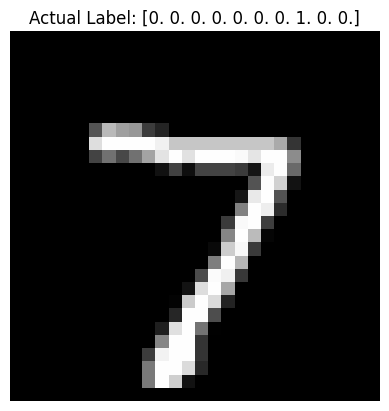

In [8]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0], cmap='gray')
plt.title("Actual Label: " + str(y_test[0]))
plt.axis('off')
plt.show()

In [9]:
import numpy as np

prediction = model.predict(x_test)

print("Predicted:", np.argmax(prediction[0]))
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted: 7
Actual: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [10]:
img = x_test[0]

# reshape (important)
img = img.reshape(1, 28, 28)

pred = model.predict(img)

print("Predicted digit:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted digit: 7


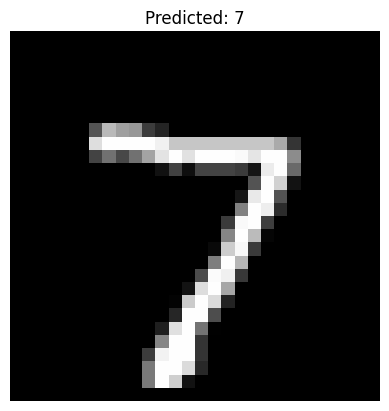

In [11]:
plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: " + str(np.argmax(prediction[0])))
plt.axis('off')
plt.show()

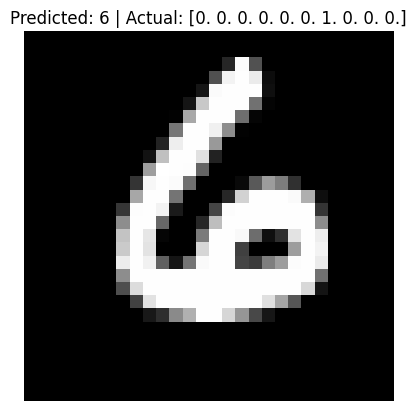

In [12]:
import random

i = random.randint(0, 10000)

plt.imshow(x_test[i], cmap='gray')
plt.title("Predicted: " + str(np.argmax(prediction[i])) + 
          " | Actual: " + str(y_test[i]))
plt.axis('off')
plt.show()